In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='annular-lodge-412305')

# quick test
test = client.query("SELECT COUNT(*) as sessions FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20170101`").to_dataframe()
print(f"Connection working — {test['sessions'][0]} sessions found")

Connection working — 1364 sessions found


In [4]:
funnel_query = """
SELECT
  COUNT(DISTINCT fullVisitorId) AS total_visitors,
  COUNT(DISTINCT CASE WHEN hits.eCommerceAction.action_type = '2' THEN fullVisitorId END) AS viewed_product,
  COUNT(DISTINCT CASE WHEN hits.eCommerceAction.action_type = '3' THEN fullVisitorId END) AS added_to_cart,
  COUNT(DISTINCT CASE WHEN hits.eCommerceAction.action_type = '6' THEN fullVisitorId END) AS completed_purchase
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
  UNNEST(hits) AS hits
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
"""
funnel_df = client.query(funnel_query).to_dataframe()
print(funnel_df)

   total_visitors  viewed_product  added_to_cart  completed_purchase
0          714167           99256          39817               10022


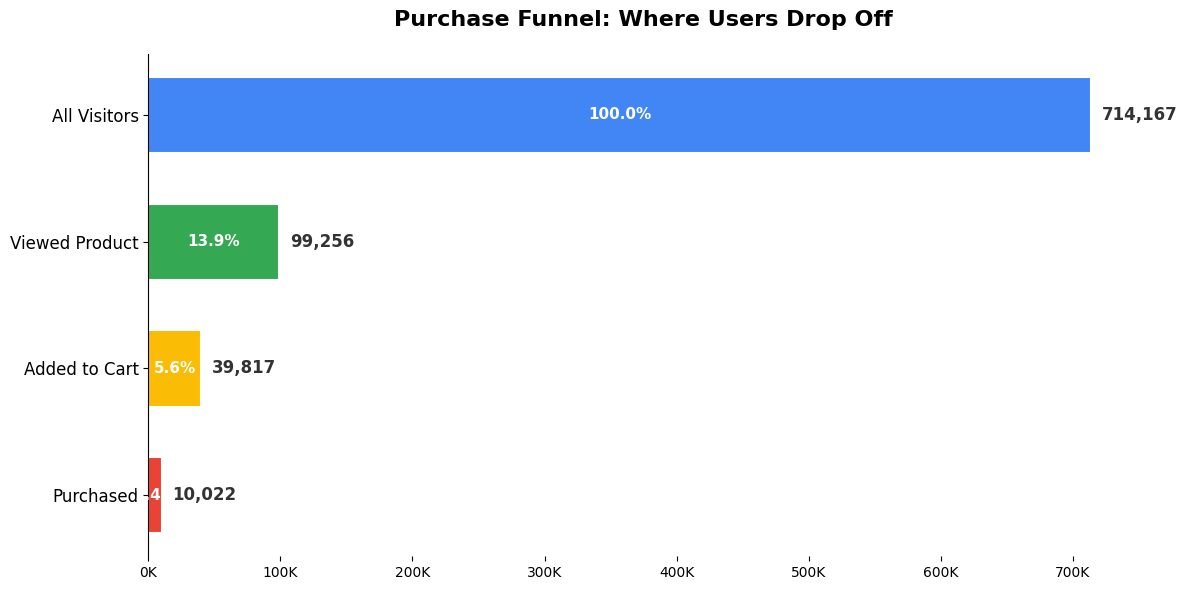


Drop-off rates:
  All Visitors → Viewed Product: 86.1% dropped
  Viewed Product → Added to Cart: 59.9% dropped
  Added to Cart → Purchased: 74.8% dropped


In [5]:
stages = ['All Visitors', 'Viewed Product', 'Added to Cart', 'Purchased']
values = [
    funnel_df['total_visitors'][0],
    funnel_df['viewed_product'][0],
    funnel_df['added_to_cart'][0],
    funnel_df['completed_purchase'][0]
]

colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335']
drop_offs = [0] + [round((1 - values[i]/values[i-1]) * 100, 1) for i in range(1, len(values))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(stages[::-1], values[::-1], color=colors[::-1], height=0.6, edgecolor='white', linewidth=1.5)

for i, (bar, val, stage) in enumerate(zip(bars, values[::-1], stages[::-1])):
    ax.text(bar.get_width() + 8000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=12, fontweight='bold', color='#333')
    pct_of_total = val / values[0] * 100
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height()/2,
            f'{pct_of_total:.1f}%', va='center', ha='center', fontsize=11, color='white', fontweight='bold')

ax.set_xlabel('')
ax.set_title('Purchase Funnel: Where Users Drop Off', fontsize=16, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.show()

print(f"\nDrop-off rates:")
for i in range(1, len(stages)):
    print(f"  {stages[i-1]} → {stages[i]}: {drop_offs[i]}% dropped")

In [6]:
channel_query = """
SELECT
  channelGrouping,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue,
  ROUND(SUM(totals.bounces) * 100.0 / COUNT(*), 2) AS bounce_rate
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY channelGrouping
ORDER BY revenue DESC
"""
channel_df = client.query(channel_query).to_dataframe()
print(channel_df)

  channelGrouping  sessions  transactions  conversion_rate    revenue  \
0        Referral    104838          5543             5.29  717600.25   
1          Direct    143026          2219             1.55  498530.03   
2  Organic Search    381561          3581             0.94  377075.81   
3         Display      6262           152             2.43  130336.56   
4     Paid Search     25326           479             1.89   47543.43   
5          Social    226117           131             0.06    8396.78   
6      Affiliates     16403             9             0.05     654.38   
7         (Other)       120             1             0.83      11.99   

   bounce_rate  
0        25.98  
1        49.56  
2        48.32  
3        35.87  
4        38.01  
5        65.24  
6        53.05  
7        46.67  


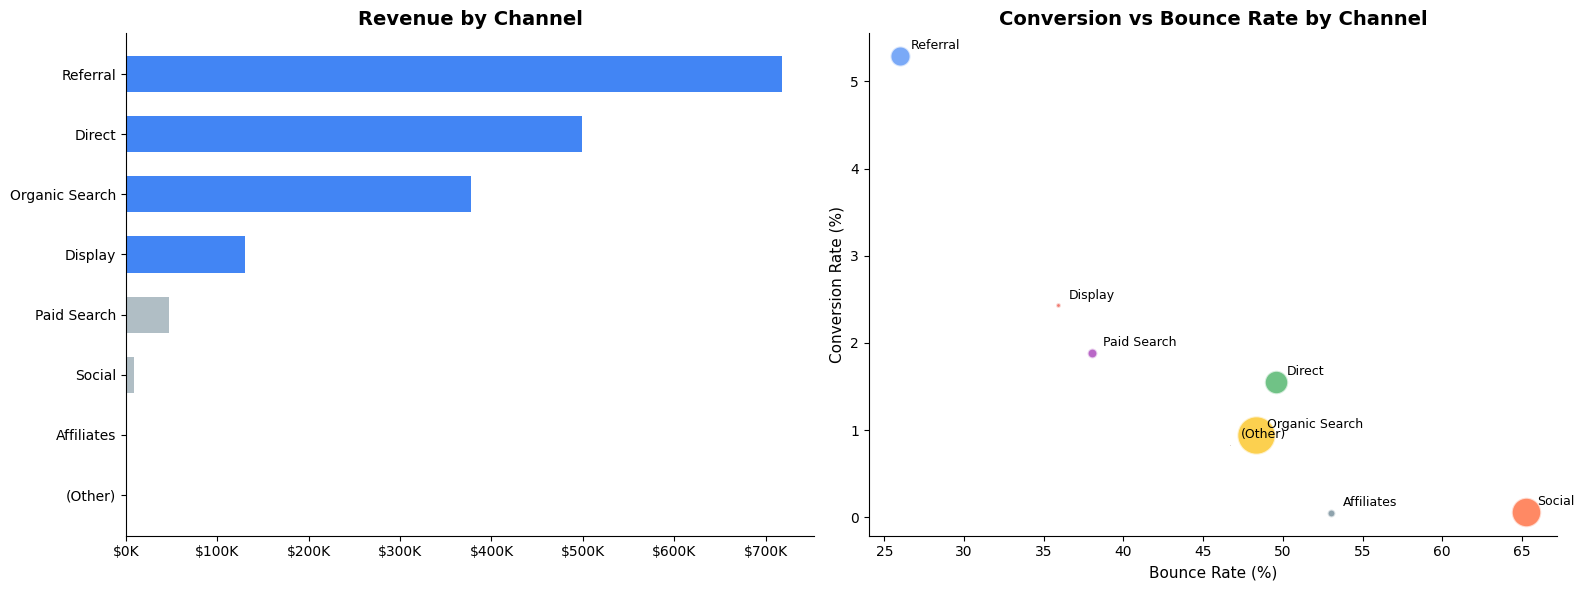

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# revenue by channel
channel_sorted = channel_df.sort_values('revenue', ascending=True)
colors_rev = ['#4285F4' if r > 100000 else '#B0BEC5' for r in channel_sorted['revenue']]
ax1.barh(channel_sorted['channelGrouping'], channel_sorted['revenue'], color=colors_rev, height=0.6)
ax1.set_title('Revenue by Channel', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.spines[['top', 'right']].set_visible(False)

# conversion rate vs bounce rate scatter
scatter_colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9C27B0', '#FF5722', '#607D8B', '#795548']
for i, row in channel_df.iterrows():
    ax2.scatter(row['bounce_rate'], row['conversion_rate'],
                s=row['sessions']/500, color=scatter_colors[i % len(scatter_colors)],
                alpha=0.7, edgecolors='white', linewidth=1.5)
    ax2.annotate(row['channelGrouping'], (row['bounce_rate'], row['conversion_rate']),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

ax2.set_xlabel('Bounce Rate (%)', fontsize=11)
ax2.set_ylabel('Conversion Rate (%)', fontsize=11)
ax2.set_title('Conversion vs Bounce Rate by Channel', fontsize=14, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
device_query = """
SELECT
  device.deviceCategory,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue,
  ROUND(SUM(totals.bounces) * 100.0 / COUNT(*), 2) AS bounce_rate
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY device.deviceCategory
ORDER BY revenue DESC
"""
device_df = client.query(device_query).to_dataframe()
print(device_df)

  deviceCategory  sessions  transactions  conversion_rate     revenue  \
0        desktop    664479         11071             1.67  1711856.29   
1         mobile    208725           866             0.41    56906.02   
2         tablet     30449           178             0.58    11386.92   

   bounce_rate  
0        49.22  
1        51.96  
2        49.62  


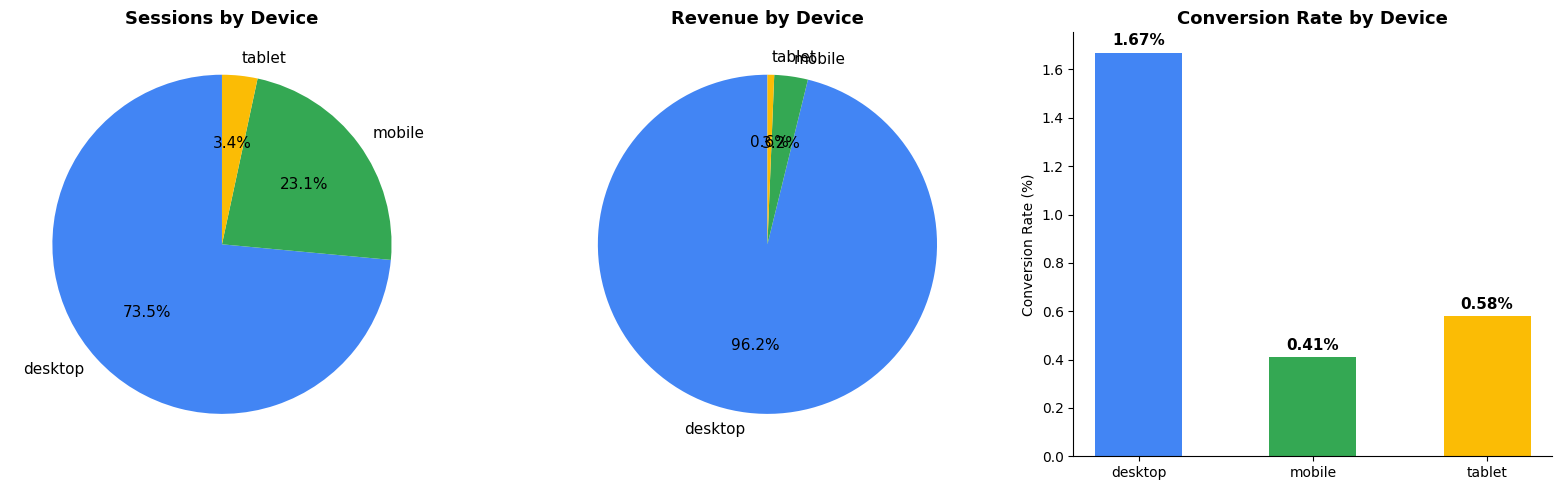


Mobile gets 23.1% of traffic but only 3.2% of revenue


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
device_colors = ['#4285F4', '#34A853', '#FBBC05']

# sessions share
axes[0].pie(device_df['sessions'], labels=device_df['deviceCategory'], colors=device_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Sessions by Device', fontsize=13, fontweight='bold')

# revenue share
axes[1].pie(device_df['revenue'], labels=device_df['deviceCategory'], colors=device_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Revenue by Device', fontsize=13, fontweight='bold')

# conversion rate comparison
axes[2].bar(device_df['deviceCategory'], device_df['conversion_rate'], color=device_colors, width=0.5)
axes[2].set_title('Conversion Rate by Device', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(device_df['conversion_rate']):
    axes[2].text(i, v + 0.03, f'{v}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nMobile gets {device_df[device_df['deviceCategory']=='mobile']['sessions'].values[0]/device_df['sessions'].sum()*100:.1f}% of traffic but only {device_df[device_df['deviceCategory']=='mobile']['revenue'].values[0]/device_df['revenue'].sum()*100:.1f}% of revenue")

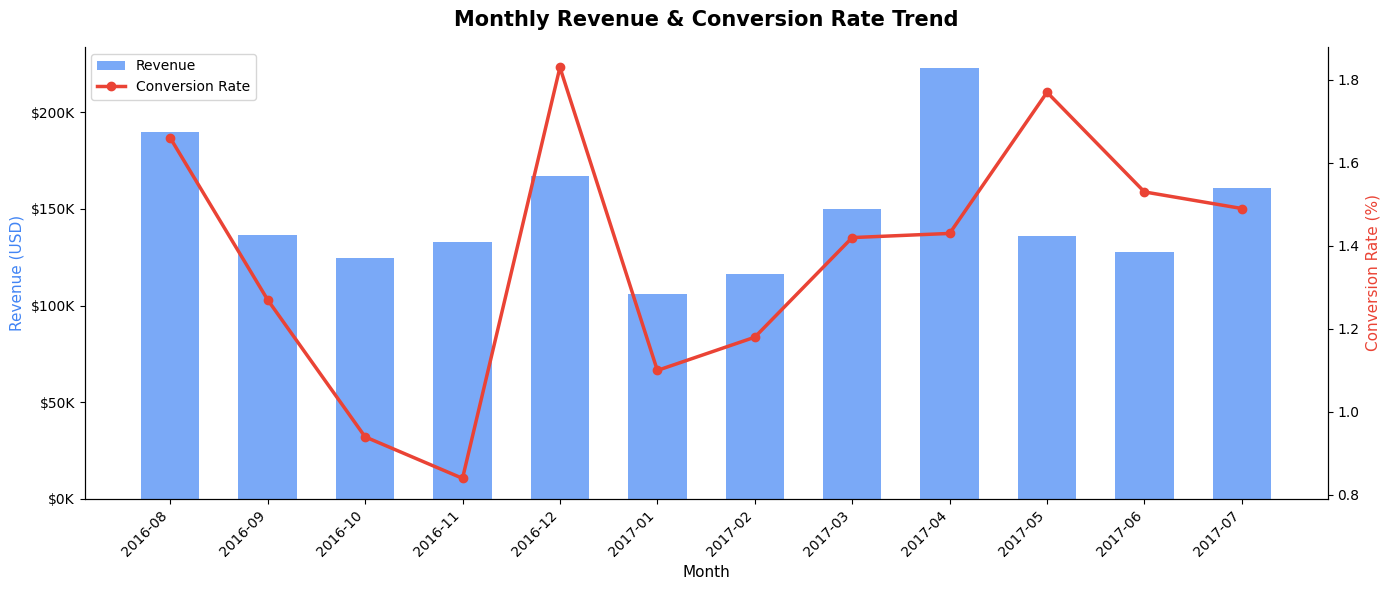

In [10]:
monthly_query = """
SELECT
  SUBSTR(_TABLE_SUFFIX, 1, 6) AS year_month,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY year_month
ORDER BY year_month
"""
monthly_df = client.query(monthly_query).to_dataframe()
monthly_df = monthly_df[monthly_df['year_month'] != '201708']  # partial month

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = range(len(monthly_df))
ax1.bar(x, monthly_df['revenue'], color='#4285F4', alpha=0.7, width=0.6, label='Revenue')
ax2.plot(x, monthly_df['conversion_rate'], color='#EA4335', marker='o', linewidth=2.5, label='Conversion Rate')

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Revenue (USD)', fontsize=11, color='#4285F4')
ax2.set_ylabel('Conversion Rate (%)', fontsize=11, color='#EA4335')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{m[:4]}-{m[4:]}" for m in monthly_df['year_month']], rotation=45, ha='right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.set_title('Monthly Revenue & Conversion Rate Trend', fontsize=15, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

plt.tight_layout()
plt.show()

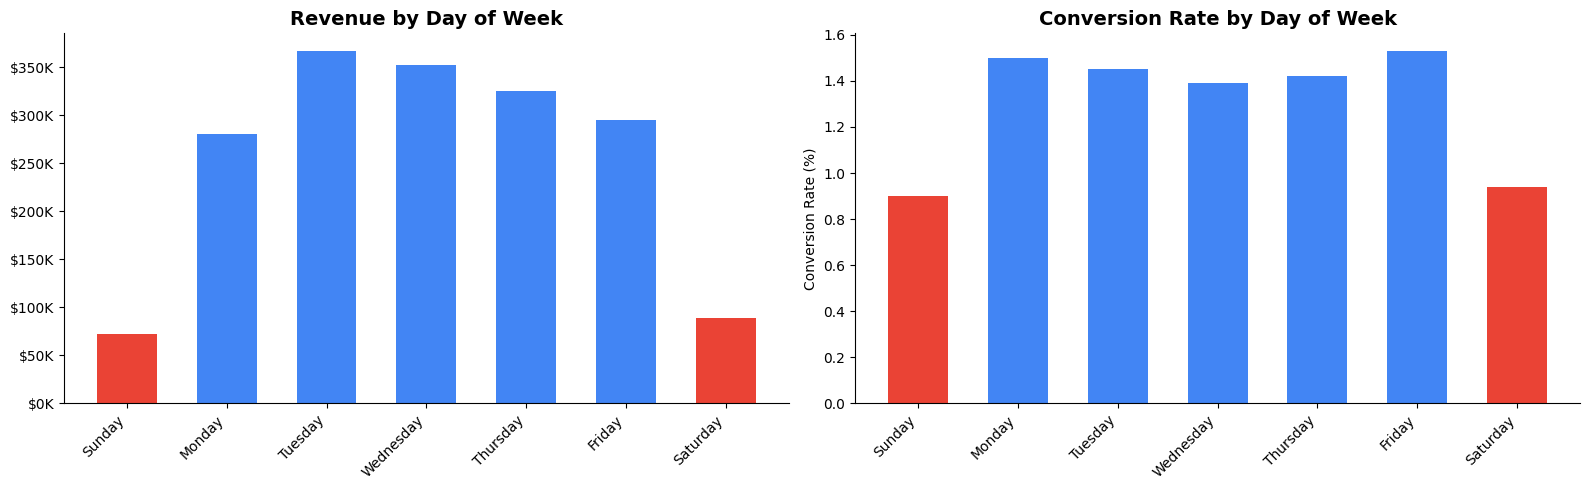

Best day: Tuesday ($366,762)
Worst day: Sunday ($72,213)


In [11]:
dow_query = """
SELECT
  FORMAT_TIMESTAMP('%A', TIMESTAMP_SECONDS(visitStartTime)) AS day_of_week,
  EXTRACT(DAYOFWEEK FROM TIMESTAMP_SECONDS(visitStartTime)) AS day_num,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY day_of_week, day_num
ORDER BY day_num
"""
dow_df = client.query(dow_query).to_dataframe()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
day_colors = ['#EA4335' if r < 100000 else '#4285F4' for r in dow_df['revenue']]

ax1.bar(dow_df['day_of_week'], dow_df['revenue'], color=day_colors, width=0.6)
ax1.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.spines[['top', 'right']].set_visible(False)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.bar(dow_df['day_of_week'], dow_df['conversion_rate'], color=day_colors, width=0.6)
ax2.set_title('Conversion Rate by Day of Week', fontsize=14, fontweight='bold')
ax2.set_ylabel('Conversion Rate (%)')
ax2.spines[['top', 'right']].set_visible(False)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"Best day: {dow_df.loc[dow_df['revenue'].idxmax(), 'day_of_week']} (${dow_df['revenue'].max():,.0f})")
print(f"Worst day: {dow_df.loc[dow_df['revenue'].idxmin(), 'day_of_week']} (${dow_df['revenue'].min():,.0f})")

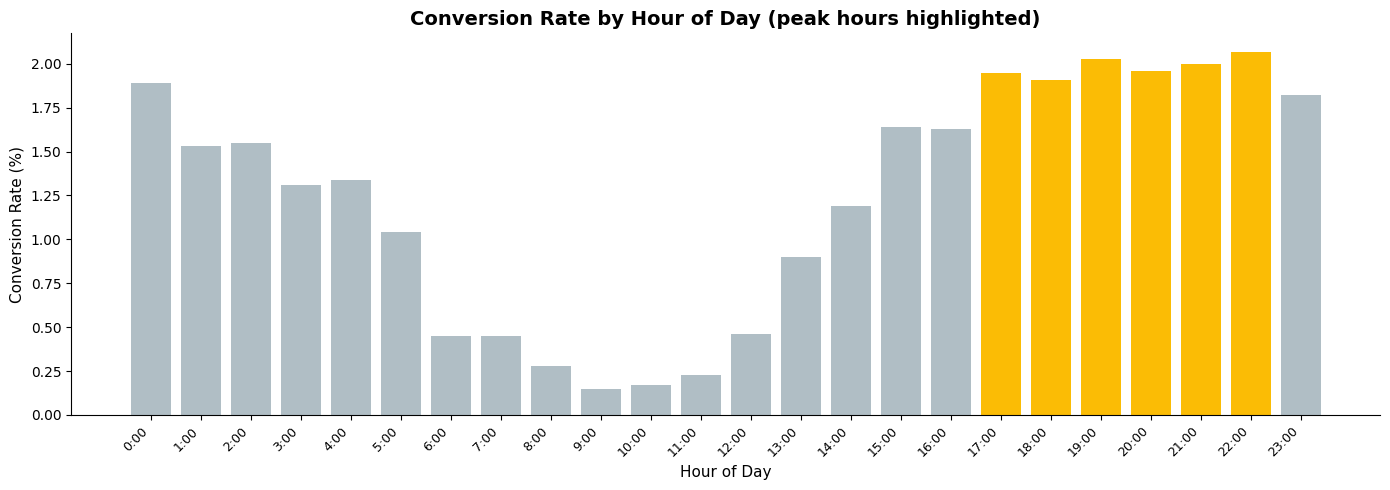

Peak hours (5PM-10PM) avg conversion: 1.99%
Morning hours (6AM-10AM) avg conversion: 0.30%


In [12]:
hour_query = """
SELECT
  EXTRACT(HOUR FROM TIMESTAMP_SECONDS(visitStartTime)) AS hour_of_day,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY hour_of_day
ORDER BY hour_of_day
"""
hour_df = client.query(hour_query).to_dataframe()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#FBBC05' if h >= 17 and h <= 22 else '#B0BEC5' for h in hour_df['hour_of_day']]
ax.bar(hour_df['hour_of_day'], hour_df['conversion_rate'], color=colors, width=0.8)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_title('Conversion Rate by Hour of Day (peak hours highlighted)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24)], rotation=45, ha='right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

peak = hour_df[(hour_df['hour_of_day'] >= 17) & (hour_df['hour_of_day'] <= 22)]
off = hour_df[(hour_df['hour_of_day'] >= 6) & (hour_df['hour_of_day'] <= 10)]
print(f"Peak hours (5PM-10PM) avg conversion: {peak['conversion_rate'].mean():.2f}%")
print(f"Morning hours (6AM-10AM) avg conversion: {off['conversion_rate'].mean():.2f}%")

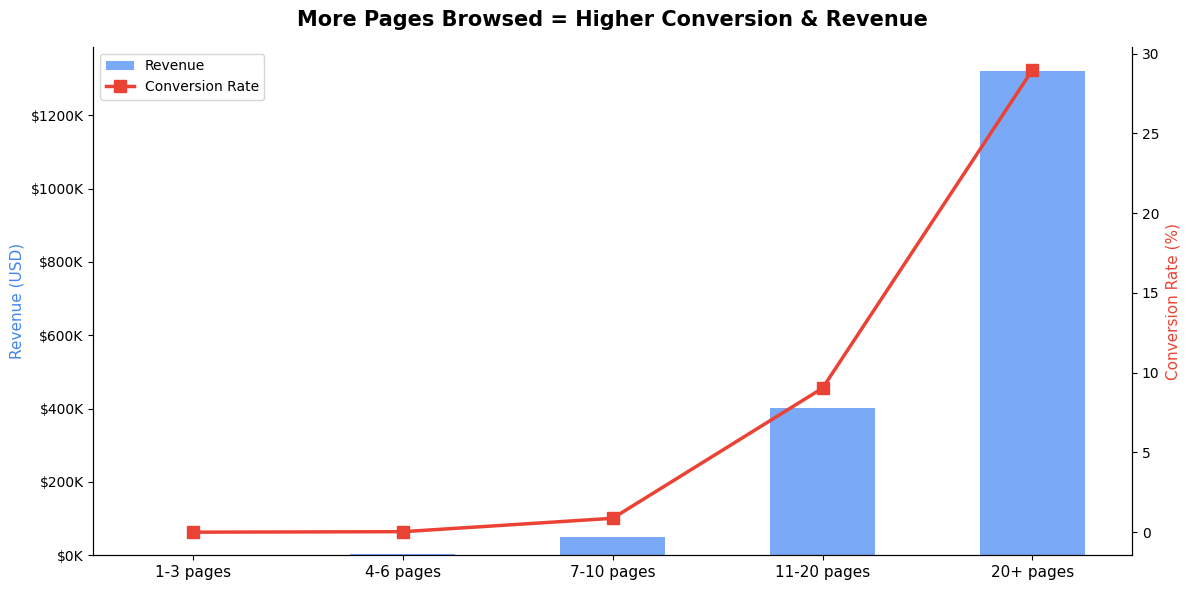

In [13]:
page_query = """
SELECT
  CASE
    WHEN totals.pageviews <= 3 THEN '1-3 pages'
    WHEN totals.pageviews <= 6 THEN '4-6 pages'
    WHEN totals.pageviews <= 10 THEN '7-10 pages'
    WHEN totals.pageviews <= 20 THEN '11-20 pages'
    ELSE '20+ pages'
  END AS pageview_bucket,
  COUNT(*) AS sessions,
  SUM(totals.transactions) AS transactions,
  ROUND(SUM(totals.transactions) * 100.0 / COUNT(*), 2) AS conversion_rate,
  ROUND(SUM(totals.totalTransactionRevenue)/1000000, 2) AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '20160801' AND '20170801'
GROUP BY pageview_bucket
ORDER BY conversion_rate DESC
"""
page_df = client.query(page_query).to_dataframe()

order = ['1-3 pages', '4-6 pages', '7-10 pages', '11-20 pages', '20+ pages']
page_df['pageview_bucket'] = pd.Categorical(page_df['pageview_bucket'], categories=order, ordered=True)
page_df = page_df.sort_values('pageview_bucket')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = range(len(page_df))
ax1.bar(x, page_df['revenue'], color='#4285F4', alpha=0.7, width=0.5, label='Revenue')
ax2.plot(x, page_df['conversion_rate'], color='#EA4335', marker='s', linewidth=2.5,
         markersize=8, label='Conversion Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(page_df['pageview_bucket'], fontsize=11)
ax1.set_ylabel('Revenue (USD)', color='#4285F4', fontsize=11)
ax2.set_ylabel('Conversion Rate (%)', color='#EA4335', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.set_title('More Pages Browsed = Higher Conversion & Revenue', fontsize=15, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

plt.tight_layout()
plt.show()